# БЛОК 1. НАСТРОЙКА ОКРУЖЕНИЯ

In [1]:
# 1.1 ИМПОРТЫ БИБЛИОТЕК

# Системные и базовые
import os
import sys
import json
import shutil
import time
import warnings
import joblib
from datetime import datetime

# Данные и визуализация
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Модели
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

# Метрики (полный набор для универсальности)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    brier_score_loss,
    log_loss,
    ConfusionMatrixDisplay
)

# Статистика
from scipy import stats
from scipy.stats import norm
import statsmodels.api as sm

# Настройки
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

In [2]:
# 1.2 ОПРЕДЕЛЕНИЕ ОКРУЖЕНИЯ И ВЕРСИИ

# Определение окружения (Colab или локально)
try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ Google Colab")
except ImportError:
    IN_COLAB = False
    print("✓ Локально / Kaggle")

# Версии библиотек (для воспроизводимости)
print("\n📦 Версии:")
print(f"   Python: {sys.version.split()[0]}")
print(f"   pandas: {pd.__version__}")
print(f"   numpy: {np.__version__}")
print(f"   sklearn: {__import__('sklearn').__version__}")
print(f"   statsmodels: {sm.__version__}")

✓ Google Colab

📦 Версии:
   Python: 3.12.13
   pandas: 2.2.2
   numpy: 2.0.2
   sklearn: 1.6.1
   statsmodels: 0.14.6


In [3]:
# 1.3 НАСТРОЙКИ ПРОЕКТА

PROJECT_NAME = 'stroke'
BASE_PATH = '/content/drive/MyDrive/ml_learning'

DEFAULT_MODEL_PARAMS = {
    'class_weight': 'balanced',
    'random_state': 42,
    'max_iter': 1000,
    'solver': 'liblinear',
    'penalty': 'l2',
    'C': 1.0
}

THRESHOLDS = np.arange(0.1, 0.95, 0.05)

# -----------------------------------------------------------------------------
# КРИТЕРИИ ВЫБОРА ЛУЧШЕЙ МОДЕЛИ
# -----------------------------------------------------------------------------
SELECTION_PRIMARY_METRIC = 'auc_roc'
SELECTION_SECONDARY_METRIC = 'FN_05'
SELECTION_MIN_RECALL = 0.7
SELECTION_REQUIRE_STABLE = True
SELECTION_GAP_THRESHOLD = 0.03
FORCE_BEST_EXPERIMENT = None

# -----------------------------------------------------------------------------
# УНИВЕРСАЛЬНАЯ ФУНКЦИЯ ПРИМЕНЕНИЯ ТРАНСФОРМАЦИЙ
# -----------------------------------------------------------------------------
def apply_transforms(X_tr, X_val, transform_rules):
    """
    Применяет трансформации к данным по правилам.

    transform_rules: dict с ключами:
        - 'drop': список колонок для удаления
        - 'poly': dict {колонка: степень}
        - 'interaction': список кортежей [(кол1, кол2), ...]
    """
    if transform_rules is None:
        return X_tr.copy(), X_val.copy()

    X_tr_new = X_tr.copy()
    X_val_new = X_val.copy()

    # 1. Удаление колонок
    if 'drop' in transform_rules:
        cols = transform_rules['drop']
        X_tr_new = X_tr_new.drop(columns=[c for c in cols if c in X_tr_new.columns])
        X_val_new = X_val_new.drop(columns=[c for c in cols if c in X_val_new.columns])

    # 2. Полиномы
    if 'poly' in transform_rules:
        for col, degree in transform_rules['poly'].items():
            if col in X_tr_new.columns:
                for d in range(2, degree + 1):
                    X_tr_new[f'{col}^{d}'] = X_tr_new[col] ** d
                    X_val_new[f'{col}^{d}'] = X_val_new[col] ** d

    # 3. Взаимодействия
    if 'interaction' in transform_rules:
        for col1, col2 in transform_rules['interaction']:
            if col1 in X_tr_new.columns and col2 in X_tr_new.columns:
                name = f'{col1}_x_{col2}'
                X_tr_new[name] = X_tr_new[col1] * X_tr_new[col2]
                X_val_new[name] = X_val_new[col1] * X_val_new[col2]

    return X_tr_new, X_val_new

# -----------------------------------------------------------------------------
# СПИСОК ЭКСПЕРИМЕНТОВ
# Формат: (название, изменения параметров, правила трансформации или None)
# -----------------------------------------------------------------------------
EXPERIMENTS_TO_RUN = [
    ("Baseline", {}, None),
    ("Без балансировки", {'class_weight': None}, None),
    ("C=0.1", {'C': 0.1}, None),
    ("C=10.0", {'C': 10.0}, None),

    # Удаление признаков
    ("Без marriage_risk", {}, {'drop': ['marriage_risk_senior_married', 'marriage_risk_senior_unmarried']}),

    # Полиномы
    ("+ age²", {}, {'poly': {'age': 2}}),
    ("Без marriage_risk + age²", {}, {'drop': ['marriage_risk_senior_married', 'marriage_risk_senior_unmarried'], 'poly': {'age': 2}}),

    # Взаимодействия
    ("+ age × glucose", {}, {'interaction': [('age', 'avg_glucose_level')]}),
    ("+ age × bmi", {}, {'interaction': [('age', 'bmi')]}),
]

print("PROJECT_NAME:", PROJECT_NAME)
print("Экспериментов:", len(EXPERIMENTS_TO_RUN))
print(f"\nКритерии выбора:")
print(f"   Основная: {SELECTION_PRIMARY_METRIC}")
print(f"   Вторичная: {SELECTION_SECONDARY_METRIC}")
print(f"   Мин. Recall: {SELECTION_MIN_RECALL}")
print(f"   Стабильность: {'✅ требуется' if SELECTION_REQUIRE_STABLE else '❌ не требуется'} (gap < {SELECTION_GAP_THRESHOLD})")
print(f"   Принудительно: {FORCE_BEST_EXPERIMENT if FORCE_BEST_EXPERIMENT else 'авто'}")

PROJECT_NAME: stroke
Экспериментов: 9

Критерии выбора:
   Основная: auc_roc
   Вторичная: FN_05
   Мин. Recall: 0.7
   Стабильность: ✅ требуется (gap < 0.03)
   Принудительно: авто


In [4]:
# 1.4 НАСТРОЙКА ПУТЕЙ

PROJECT_PATH = os.path.join(BASE_PATH, 'datasets', PROJECT_NAME)
SPLITS_PATH = os.path.join(PROJECT_PATH, 'splits')
MODELS_PATH = os.path.join(PROJECT_PATH, 'models')
REPORTS_PATH = os.path.join(PROJECT_PATH, 'reports')

# Создание папок, если их нет
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(REPORTS_PATH, exist_ok=True)

print("PROJECT_PATH:", PROJECT_PATH)
print("SPLITS_PATH:", SPLITS_PATH)
print("MODELS_PATH:", MODELS_PATH)

PROJECT_PATH: /content/drive/MyDrive/ml_learning/datasets/stroke
SPLITS_PATH: /content/drive/MyDrive/ml_learning/datasets/stroke/splits
MODELS_PATH: /content/drive/MyDrive/ml_learning/datasets/stroke/models


In [5]:
# 1.5 МОНТИРОВАНИЕ ГУГЛ ДРАЙВ

if IN_COLAB:
    if BASE_PATH.startswith('/content/drive'):
        if os.path.ismount('/content/drive'):
            print("✓ Google Drive уже смонтирован")
        else:
            print("📂 Монтирование Google Drive...")
            if os.path.exists('/content/drive'):
                shutil.rmtree('/content/drive')
            drive.mount('/content/drive')
            print("✓ Google Drive смонтирован")
else:
    print("✓ Локальная среда, монтирование не требуется")

✓ Google Drive уже смонтирован


In [6]:
# 1.6 ЗАГРУЗКА МЕТАДАННЫХ

metadata_path = os.path.join(PROJECT_PATH, 'production_metadata.json')

if not os.path.exists(metadata_path):
    raise FileNotFoundError(f"❌ Файл не найден: {metadata_path}")

with open(metadata_path, 'r', encoding='utf-8') as f:
    prod_metadata = json.load(f)

TARGET_COLUMN = prod_metadata['target_column']
TASK_TYPE = prod_metadata['task_type']
FEATURE_COLUMNS = prod_metadata['features']['all_features']
FINAL_COUNT = prod_metadata['features']['final_count']

print(f"Целевая переменная: {TARGET_COLUMN}")
print(f"Тип задачи: {TASK_TYPE}")
print(f"Признаков: {FINAL_COUNT}")
print(f"Признаки: {FEATURE_COLUMNS}")

Целевая переменная: stroke
Тип задачи: classification
Признаков: 6
Признаки: ['age', 'avg_glucose_level', 'bmi', 'cardio_risk', 'marriage_risk_senior_married', 'marriage_risk_senior_unmarried']


In [7]:
# 1.7 ЗАГРУЗКА ДАННЫХ

X_train = pd.read_csv(os.path.join(SPLITS_PATH, 'X_train_scaled.csv'))
y_train = pd.read_csv(os.path.join(SPLITS_PATH, 'y_train.csv')).iloc[:, 0]

X_val = pd.read_csv(os.path.join(SPLITS_PATH, 'X_val_final.csv'))
y_val = pd.read_csv(os.path.join(SPLITS_PATH, 'y_val_final.csv')).iloc[:, 0]

X_test = pd.read_csv(os.path.join(SPLITS_PATH, 'X_test_final.csv'))
y_test = pd.read_csv(os.path.join(SPLITS_PATH, 'y_test_final.csv')).iloc[:, 0]

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

Train: (2911, 6)
Val:   (971, 6)
Test:  (971, 6)


In [8]:
# 1.8 ПРОВЕРКА СООТВЕТСТВИЯ ПРИЗНАКОВ И БАЛАНСА КЛАССОВ

# Проверка соответствия признаков
train_cols = set(X_train.columns)
meta_cols = set(FEATURE_COLUMNS)

if train_cols == meta_cols:
    print("✓ Состав признаков соответствует метаданным")
else:
    print("⚠️ Несоответствие:")
    print(f"   В метаданных, но не в данных: {meta_cols - train_cols}")
    print(f"   В данных, но не в метаданных: {train_cols - meta_cols}")

# Проверка пропусков
nulls = X_train.isnull().sum().sum() + X_val.isnull().sum().sum() + X_test.isnull().sum().sum()
if nulls == 0:
    print("✓ Пропусков нет")
else:
    print(f"⚠️ Обнаружены пропуски: {nulls}")

# Баланс классов в train
class_counts = y_train.value_counts()
print(f"\nБаланс классов в TRAIN:")
for cls, count in class_counts.items():
    print(f"   Класс {cls}: {count} ({count/len(y_train)*100:.1f}%)")
print(f"   Соотношение: {class_counts.max() / class_counts.min():.1f}:1")

✓ Состав признаков соответствует метаданным
✓ Пропусков нет

Баланс классов в TRAIN:
   Класс 0: 2786 (95.7%)
   Класс 1: 125 (4.3%)
   Соотношение: 22.3:1


# БЛОК 2. ФУНКЦИИ ДЛЯ ЭКСПЕРИМЕНТОВ

In [9]:
# 2.1 УНИВЕРСАЛЬНАЯ ФУНКЦИЯ ЗАПУСКА ЭКСПЕРИМЕНТА

def run_experiment(model, experiment_name, X_train, y_train, X_val, y_val, thresholds=THRESHOLDS):
    """
    Унифицированный запуск одного эксперимента.
    """

    start_time = time.time()

    # Обучение
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # Предсказания
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_val_proba = model.predict_proba(X_val)[:, 1]

    # Метрики на train (для оценки переобучения)
    train_auc = roc_auc_score(y_train, y_train_proba)

    # Основные метрики на val (не зависящие от порога)
    auc_roc = roc_auc_score(y_val, y_val_proba)
    auc_pr = average_precision_score(y_val, y_val_proba)
    brier = brier_score_loss(y_val, y_val_proba)
    logloss = log_loss(y_val, y_val_proba)
    gap_auc = train_auc - auc_roc

    # Расчёт метрик при всех порогах
    results = []
    for thresh in thresholds:
        y_pred = (y_val_proba >= thresh).astype(int)

        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        mcc = matthews_corrcoef(y_val, y_pred)

        cm = confusion_matrix(y_val, y_pred)
        TN, FP, FN, TP = cm.ravel()

        results.append({
            'threshold': thresh,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'mcc': mcc,
            'TP': TP,
            'FN': FN,
            'FP': FP,
            'TN': TN,
            'pred_positives': TP + FP
        })

    df_thresholds = pd.DataFrame(results)

    # Поиск оптимального порога по F1
    best_f1_idx = df_thresholds['f1'].idxmax()
    best_row = df_thresholds.loc[best_f1_idx]

    # Поиск оптимального порога по Youden's J
    fpr, tpr, roc_thresholds = roc_curve(y_val, y_val_proba)
    youden_idx = np.argmax(tpr - fpr)
    youden_threshold = roc_thresholds[youden_idx] if youden_idx < len(roc_thresholds) else 0.5

    # Метрики при пороге 0.5
    at_05 = df_thresholds[df_thresholds['threshold'] == 0.5]
    if len(at_05) > 0:
        at_05 = at_05.iloc[0]
    else:
        closest_idx = (df_thresholds['threshold'] - 0.5).abs().idxmin()
        at_05 = df_thresholds.loc[closest_idx]

    # Сводка
    summary = {
        'experiment': experiment_name,
        'train_time': train_time,
        'train_auc': train_auc,
        'auc_roc': auc_roc,
        'gap_auc': gap_auc,
        'auc_pr': auc_pr,
        'brier': brier,
        'logloss': logloss,
        'best_threshold_f1': best_row['threshold'],
        'best_f1': best_row['f1'],
        'best_recall': best_row['recall'],
        'best_precision': best_row['precision'],
        'best_mcc': best_row['mcc'],
        'youden_threshold': youden_threshold,
        'recall_05': at_05['recall'],
        'precision_05': at_05['precision'],
        'f1_05': at_05['f1'],
        'mcc_05': at_05['mcc'],
        'FN_05': at_05['FN'],
        'FP_05': at_05['FP'],
        'TP_05': at_05['TP'],
        'TN_05': at_05['TN'],
        'params': str(model.get_params())
    }

    return df_thresholds, summary, model

In [10]:
# 2.2 ФУНКЦИЯ СРАВНЕНИЯ МОДЕЛЕЙ

def compare_models(summaries_list, primary_metric='auc_roc', min_recall=0.0, gap_threshold=0.03):
    """
    Создаёт сводную таблицу сравнения всех экспериментов с оценкой стабильности.

    Параметры:
    ----------
    summaries_list : list
        Список словарей summary из функции run_experiment()
    primary_metric : str
        Метрика для сортировки
    min_recall : float
        Минимальный Recall для фильтрации
    gap_threshold : float
        Порог для определения переобучения (разница train - val)

    Возвращает:
    -----------
    DataFrame с отсортированными результатами
    """

    df = pd.DataFrame(summaries_list)

    # Оценка стабильности (если есть train_auc)
    if 'train_auc' in df.columns:
        df['gap_auc'] = df['train_auc'] - df['auc_roc']
        df['stability'] = df['gap_auc'].apply(
            lambda x: '✅' if abs(x) <= gap_threshold else ('🟡' if abs(x) <= 0.05 else '🔴')
        )
    else:
        # Если train_auc нет, считаем gap = 0 (заглушка)
        df['gap_auc'] = 0.0
        df['stability'] = '✅'

    # Фильтрация по минимальному Recall
    if min_recall > 0:
        df = df[df['recall_05'] >= min_recall].copy()
        if len(df) == 0:
            print(f"⚠️ Нет моделей с Recall >= {min_recall}")
            return pd.DataFrame()
        print(f"Отфильтровано: Recall >= {min_recall} (осталось {len(df)} экспериментов)")

    # Сортировка
    ascending = False if primary_metric != 'logloss' else True
    df = df.sort_values(primary_metric, ascending=ascending)

    # Выбор колонок для отображения
    display_cols = [
        'experiment',
        'auc_roc',
        'auc_pr',
        'best_f1',
        'best_threshold_f1',
        'recall_05',
        'precision_05',
        'f1_05',
        'FN_05',
        'FP_05',
        'stability'
    ]

    # Оставляем только те колонки, которые есть
    available_cols = [c for c in display_cols if c in df.columns]

    return df[available_cols]

In [11]:
# 2.3 ФУНКЦИЯ ВЫБОРА ЛУЧШЕЙ МОДЕЛИ

def select_best_model(comparison_df, primary_metric='auc_roc', secondary_metric='FN_05',
                      min_recall=0.7, require_stable=True, gap_threshold=0.03):
    """
    Автоматически выбирает лучшую модель с учётом стабильности.
    """

    df = comparison_df.copy()

    # Фильтр по стабильности
    if require_stable and 'stability' in df.columns:
        df_stable = df[df['stability'] == '✅'].copy()
        if len(df_stable) == 0:
            print(f"⚠️ Нет стабильных моделей (stability != ✅)")
            print("   Расширяем поиск на 🟡 модели...")
            df = df[df['stability'].isin(['✅', '🟡'])].copy()
        else:
            df = df_stable
            print(f"✓ Отфильтровано стабильных моделей: {len(df)}")

    # Фильтр по Recall
    valid = df[df['recall_05'] >= min_recall]

    if len(valid) == 0:
        print(f"⚠️ Нет моделей с Recall >= {min_recall}")
        best = df.loc[df['recall_05'].idxmax()]
    else:
        ascending_secondary = True if secondary_metric in ['FN_05', 'FP_05', 'logloss'] else False
        valid = valid.sort_values([primary_metric, secondary_metric], ascending=[False, ascending_secondary])
        best = valid.iloc[0]

    print("="*60)
    print("🏆 АВТОМАТИЧЕСКИЙ ВЫБОР ЛУЧШЕЙ МОДЕЛИ")
    print("="*60)
    print(f"Первичная: {primary_metric} | Вторичная: {secondary_metric} | Мин. Recall: {min_recall}")
    print(f"Требовать стабильность: {require_stable}")
    print()
    print(f"✅ Выбрана: {best['experiment']}")
    print(f"   ROC-AUC: {best['auc_roc']:.4f} | Recall@0.5: {best['recall_05']:.4f} | FN: {best['FN_05']:.0f}")
    print(f"   Стабильность: {best.get('stability', '?')} (gap_auc = {best.get('gap_auc', 0):.4f})")
    print("="*60)

    return best

In [12]:
# 2.4 ФУНКЦИЯ ДЛЯ ВИЗУАЛИЗАЦИИ СРАВНЕНИЯ ЭКСПЕРИМЕНТОВ

def plot_experiments_comparison(comparison_df, save_path=None):
    """
    Визуализирует сравнение всех экспериментов.

    Параметры:
    ----------
    comparison_df : DataFrame
        Таблица сравнения из compare_models()
    save_path : str, optional
        Путь для сохранения графика
    """

    df = comparison_df.copy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # График 1: ROC-AUC vs Recall@0.5
    ax1 = axes[0]
    for i, row in df.iterrows():
        ax1.scatter(row['recall_05'], row['auc_roc'], s=100, alpha=0.7)
        # Берем короткое имя эксперимента (первые 3 слова или до 20 символов)
        short_name = row['experiment'].split(' ')[0] if len(row['experiment'].split()) > 1 else row['experiment'][:15]
        ax1.annotate(short_name, (row['recall_05'], row['auc_roc']), fontsize=9, ha='center', va='bottom')

    ax1.set_xlabel('Recall @ 0.5')
    ax1.set_ylabel('ROC-AUC')
    ax1.set_title('ROC-AUC vs Recall')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0.5, 1)

    # График 2: FN vs FP
    ax2 = axes[1]
    for i, row in df.iterrows():
        ax2.scatter(row['FP_05'], row['FN_05'], s=100, alpha=0.7)
        short_name = row['experiment'].split(' ')[0] if len(row['experiment'].split()) > 1 else row['experiment'][:15]
        ax2.annotate(short_name, (row['FP_05'], row['FN_05']), fontsize=9, ha='center', va='bottom')

    ax2.set_xlabel('FP (ложные тревоги)')
    ax2.set_ylabel('FN (пропущенные инсульты)')
    ax2.set_title('Ошибки модели')
    ax2.grid(True, alpha=0.3)

    # Добавляем стрелку в "идеальный" угол (0,0)
    ax2.annotate('ИДЕАЛ', xy=(0, 0), xytext=(max(df['FP_05'])*0.1, max(df['FN_05'])*0.1),
                 arrowprops=dict(arrowstyle='->', color='green'), fontsize=10, color='green')

    # График 3: Precision vs Recall
    ax3 = axes[2]
    for i, row in df.iterrows():
        ax3.scatter(row['recall_05'], row['precision_05'], s=100, alpha=0.7)
        short_name = row['experiment'].split(' ')[0] if len(row['experiment'].split()) > 1 else row['experiment'][:15]
        ax3.annotate(short_name, (row['recall_05'], row['precision_05']), fontsize=9, ha='center', va='bottom')

    ax3.set_xlabel('Recall @ 0.5')
    ax3.set_ylabel('Precision @ 0.5')
    ax3.set_title('Precision vs Recall')
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(0, 1)
    ax3.set_ylim(0, max(df['precision_05']) * 1.1 if max(df['precision_05']) > 0 else 0.5)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()

    # Автоматические выводы
    print("\n" + "="*60)
    print("📊 АВТОМАТИЧЕСКИЕ ВЫВОДЫ ПО СРАВНЕНИЮ")
    print("="*60)

    best_auc = df.loc[df['auc_roc'].idxmax()]
    best_recall = df.loc[df['recall_05'].idxmax()]
    best_f1 = df.loc[df['f1_05'].idxmax()]
    best_precision = df.loc[df['precision_05'].idxmax()]

    print(f"🏆 Лучшая ROC-AUC: {best_auc['experiment']} (AUC={best_auc['auc_roc']:.4f})")
    print(f"🏆 Лучший Recall: {best_recall['experiment']} (Recall={best_recall['recall_05']:.4f}, FN={best_recall['FN_05']:.0f})")
    print(f"🏆 Лучший F1: {best_f1['experiment']} (F1={best_f1['f1_05']:.4f})")
    print(f"🏆 Лучшая Precision: {best_precision['experiment']} (Precision={best_precision['precision_05']:.4f})")
    print("="*60)

# БЛОК 3. ЗАПУСК ЭКСПЕРИМЕНТОВ

In [13]:
# 3.1 АВТОМАТИЧЕСКИЙ ЗАПУСК ВСЕХ ЭКСПЕРИМЕНТОВ

all_summaries = []
all_thresholds = {}

for exp_name, param_changes, transform_rules in EXPERIMENTS_TO_RUN:
    print(f"\n🔄 {exp_name}...")

    # Применяем трансформации
    X_train_exp, X_val_exp = apply_transforms(X_train, X_val, transform_rules)

    # Создание модели с изменёнными параметрами
    params = DEFAULT_MODEL_PARAMS.copy()
    params.update(param_changes)
    model = LogisticRegression(**params)

    # Запуск эксперимента
    df_thresh, summary, _ = run_experiment(
        model, exp_name,
        X_train_exp, y_train,
        X_val_exp, y_val
    )

    all_summaries.append(summary)
    all_thresholds[exp_name] = df_thresh

    print(f"   ✓ ROC-AUC: {summary['auc_roc']:.4f} | Recall@0.5: {summary['recall_05']:.4f} | FN@0.5: {summary['FN_05']:.0f}")

print("\n" + "="*50)
print(f"✅ Завершено экспериментов: {len(all_summaries)}")
print("="*50)


🔄 Baseline...
   ✓ ROC-AUC: 0.8736 | Recall@0.5: 0.8810 | FN@0.5: 5

🔄 Без балансировки...
   ✓ ROC-AUC: 0.8755 | Recall@0.5: 0.0000 | FN@0.5: 42

🔄 C=0.1...
   ✓ ROC-AUC: 0.8743 | Recall@0.5: 0.8810 | FN@0.5: 5

🔄 C=10.0...
   ✓ ROC-AUC: 0.8736 | Recall@0.5: 0.8810 | FN@0.5: 5

🔄 Без marriage_risk...
   ✓ ROC-AUC: 0.8735 | Recall@0.5: 0.8333 | FN@0.5: 7

🔄 + age²...
   ✓ ROC-AUC: 0.8736 | Recall@0.5: 0.8810 | FN@0.5: 5

🔄 Без marriage_risk + age²...
   ✓ ROC-AUC: 0.8736 | Recall@0.5: 0.8333 | FN@0.5: 7

🔄 + age × glucose...
   ✓ ROC-AUC: 0.8720 | Recall@0.5: 0.8810 | FN@0.5: 5

🔄 + age × bmi...
   ✓ ROC-AUC: 0.8735 | Recall@0.5: 0.8810 | FN@0.5: 5

✅ Завершено экспериментов: 9


# БЛОК 4. СРАВНЕНИЕ ЭКСПЕРИМЕНТОВ

In [14]:
# 4.1 СВОДНАЯ ТАБЛИЦА ВСЕХ ЭКСПЕРИМЕНТОВ

comparison_df = compare_models(
    all_summaries,
    primary_metric=SELECTION_PRIMARY_METRIC,
    min_recall=0.0,  # без фильтрации, чтобы видеть все
    gap_threshold=SELECTION_GAP_THRESHOLD
)

print("📊 СВОДНАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ")
print("="*100)
display(comparison_df)

📊 СВОДНАЯ ТАБЛИЦА ЭКСПЕРИМЕНТОВ


,experiment,auc_roc,auc_pr,best_f1,best_threshold_f1,recall_05,precision_05,f1_05,FN_05,FP_05,stability
1,Без балансировки,0.8755,0.2131,0.3140,0.20,0.0000,0.0000,0.0000,42.0,0.0,🟡
2,C=0.1,0.8743,0.2096,0.3312,0.80,0.8810,0.1135,0.2011,5.0,289.0,🟡
6,Без marriage_risk + age²,0.8736,0.2162,0.3171,0.70,0.8333,0.1190,0.2083,7.0,259.0,🟡
0,Baseline,0.8736,0.2094,0.3200,0.85,0.8810,0.1098,0.1953,5.0,300.0,🟡
3,C=10.0,0.8736,0.2096,0.3291,0.85,0.8810,0.1091,0.1942,5.0,302.0,🟡
5,+ age²,0.8736,0.2090,0.3108,0.85,0.8810,0.1095,0.1947,5.0,301.0,🟡
4,Без marriage_risk,0.8735,0.2106,0.3308,0.75,0.8333,0.1316,0.2273,7.0,231.0,🟡
8,+ age × bmi,0.8735,0.2093,0.3200,0.85,0.8810,0.1098,0.1953,5.0,300.0,🟡
7,+ age × glucose,0.8720,0.2158,0.3193,0.90,0.8810,0.1095,0.1947,5.0,301.0,🟡


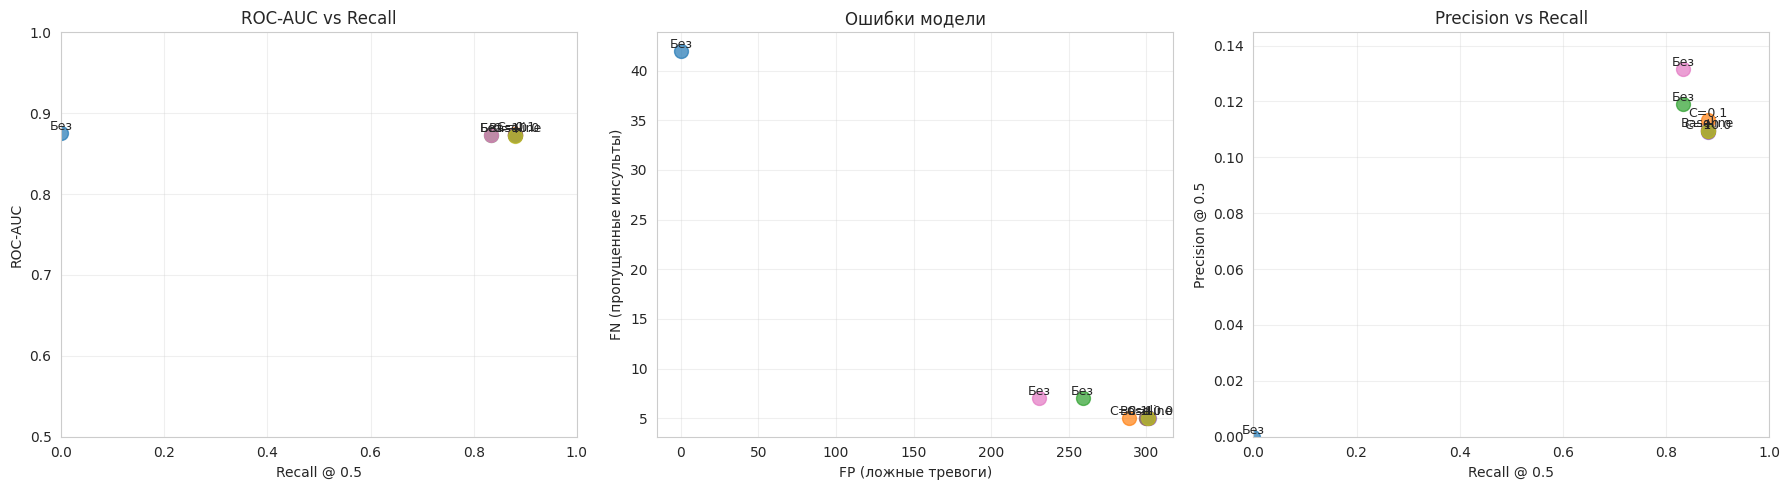


📊 АВТОМАТИЧЕСКИЕ ВЫВОДЫ ПО СРАВНЕНИЮ
🏆 Лучшая ROC-AUC: Без балансировки (AUC=0.8755)
🏆 Лучший Recall: C=0.1 (Recall=0.8810, FN=5)
🏆 Лучший F1: Без marriage_risk (F1=0.2273)
🏆 Лучшая Precision: Без marriage_risk (Precision=0.1316)


In [15]:
# 4.2 ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ ЭКСПЕРИМЕНТОВ

plot_experiments_comparison(comparison_df)

In [16]:
# 4.4 ЛУЧШИЕ МОДЕЛИ ПО РАЗНЫМ КРИТЕРИЯМ

print("\n" + "="*80)
print("📊 ЛУЧШИЕ МОДЕЛИ ПО РАЗНЫМ КРИТЕРИЯМ")
print("="*80)

# Функция для безопасного получения лучшей модели
def get_best_by_metric(df, metric, ascending=False):
    idx = df[metric].idxmax() if not ascending else df[metric].idxmin()
    return df.loc[idx]

# По ROC-AUC
best_auc = get_best_by_metric(comparison_df, 'auc_roc')
print(f"\n🏆 По ROC-AUC:")
print(f"   {best_auc['experiment']}")
print(f"   AUC={best_auc['auc_roc']:.4f}, Recall={best_auc['recall_05']:.4f}, FN={best_auc['FN_05']:.0f}")

# По Recall@0.5
best_rec = get_best_by_metric(comparison_df, 'recall_05')
print(f"\n🏆 По Recall@0.5:")
print(f"   {best_rec['experiment']}")
print(f"   Recall={best_rec['recall_05']:.4f}, AUC={best_rec['auc_roc']:.4f}, FN={best_rec['FN_05']:.0f}")

# По F1@0.5
best_f1 = get_best_by_metric(comparison_df, 'f1_05')
print(f"\n🏆 По F1@0.5:")
print(f"   {best_f1['experiment']}")
print(f"   F1={best_f1['f1_05']:.4f}, AUC={best_f1['auc_roc']:.4f}, Recall={best_f1['recall_05']:.4f}")

# По Precision@0.5
best_prec = get_best_by_metric(comparison_df, 'precision_05')
print(f"\n🏆 По Precision@0.5:")
print(f"   {best_prec['experiment']}")
print(f"   Precision={best_prec['precision_05']:.4f}, AUC={best_prec['auc_roc']:.4f}, Recall={best_prec['recall_05']:.4f}")

# По минимуму FN (пропущенных инсультов)
best_fn = get_best_by_metric(comparison_df, 'FN_05', ascending=True)
print(f"\n🏆 По минимуму FN (пропущено):")
print(f"   {best_fn['experiment']}")
print(f"   FN={best_fn['FN_05']:.0f}, Recall={best_fn['recall_05']:.4f}, AUC={best_fn['auc_roc']:.4f}")

# ТОП-3 по основной метрике
print(f"\n📋 ТОП-3 ПО {SELECTION_PRIMARY_METRIC.upper()}:")
top3 = comparison_df.nlargest(3, SELECTION_PRIMARY_METRIC)[
    ['experiment', SELECTION_PRIMARY_METRIC, 'recall_05', 'precision_05', 'FN_05']
]
display(top3.round(4))

print("="*80)


📊 ЛУЧШИЕ МОДЕЛИ ПО РАЗНЫМ КРИТЕРИЯМ

🏆 По ROC-AUC:
   Без балансировки
   AUC=0.8755, Recall=0.0000, FN=42

🏆 По Recall@0.5:
   C=0.1
   Recall=0.8810, AUC=0.8743, FN=5

🏆 По F1@0.5:
   Без marriage_risk
   F1=0.2273, AUC=0.8735, Recall=0.8333

🏆 По Precision@0.5:
   Без marriage_risk
   Precision=0.1316, AUC=0.8735, Recall=0.8333

🏆 По минимуму FN (пропущено):
   C=0.1
   FN=5, Recall=0.8810, AUC=0.8743

📋 ТОП-3 ПО AUC_ROC:


,experiment,auc_roc,recall_05,precision_05,FN_05
1,Без балансировки,0.8755,0.0000,0.0000,42.0
2,C=0.1,0.8743,0.8810,0.1135,5.0
6,Без marriage_risk + age²,0.8736,0.8333,0.1190,7.0


In [17]:
# 4.3 ВЫБОР ЛУЧШЕЙ МОДЕЛИ

if FORCE_BEST_EXPERIMENT is not None:
    mask = comparison_df['experiment'] == FORCE_BEST_EXPERIMENT
    if mask.any():
        best_model_row = comparison_df[mask].iloc[0]
        print("="*60)
        print("🔧 ПРИНУДИТЕЛЬНЫЙ ВЫБОР МОДЕЛИ")
        print("="*60)
        print(f"✅ Выбрана: {best_model_row['experiment']}")
        print(f"   ROC-AUC: {best_model_row['auc_roc']:.4f} | Recall: {best_model_row['recall_05']:.4f}")
        print(f"   Стабильность: {best_model_row.get('stability', '?')}")
        print("="*60)
    else:
        print(f"⚠️ Эксперимент '{FORCE_BEST_EXPERIMENT}' не найден!")
        FORCE_BEST_EXPERIMENT = None

if FORCE_BEST_EXPERIMENT is None:
    best_model_row = select_best_model(
        comparison_df,
        primary_metric=SELECTION_PRIMARY_METRIC,
        secondary_metric=SELECTION_SECONDARY_METRIC,
        min_recall=SELECTION_MIN_RECALL,
        require_stable=SELECTION_REQUIRE_STABLE,
        gap_threshold=SELECTION_GAP_THRESHOLD
    )

⚠️ Нет стабильных моделей (stability != ✅)
   Расширяем поиск на 🟡 модели...
🏆 АВТОМАТИЧЕСКИЙ ВЫБОР ЛУЧШЕЙ МОДЕЛИ
Первичная: auc_roc | Вторичная: FN_05 | Мин. Recall: 0.7
Требовать стабильность: True

✅ Выбрана: C=0.1
   ROC-AUC: 0.8743 | Recall@0.5: 0.8810 | FN: 5
   Стабильность: 🟡 (gap_auc = 0.0000)


# БЛОК 5. АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ

In [18]:
# 5.1 МЕТРИКИ ПРИ ВСЕХ ПОРОГАХ

best_experiment_name = best_model_row['experiment']
df_thresh_best = all_thresholds[best_experiment_name]

print(f"📊 Детальные метрики для: {best_experiment_name}")
print("="*80)
display(df_thresh_best.round(4))

📊 Детальные метрики для: C=0.1


,threshold,precision,recall,f1,mcc,TP,FN,FP,TN,pred_positives
0,0.10,0.0608,1.0000,0.1146,0.1353,42,0,649,280,691
1,0.15,0.0671,1.0000,0.1257,0.1578,42,0,584,345,626
2,0.20,0.0728,1.0000,0.1357,0.1757,42,0,535,394,577
3,0.25,0.0800,1.0000,0.1481,0.1960,42,0,483,446,525
4,0.30,0.0875,1.0000,0.1609,0.2150,42,0,438,491,480
5,0.35,0.0950,1.0000,0.1736,0.2326,42,0,400,529,442
6,0.40,0.0993,0.9762,0.1802,0.2369,41,1,372,557,413
7,0.45,0.1024,0.9048,0.1840,0.2287,38,4,333,596,371
8,0.50,0.1135,0.8810,0.2011,0.2455,37,5,289,640,326
9,0.55,0.1224,0.8333,0.2134,0.2513,35,7,251,678,286


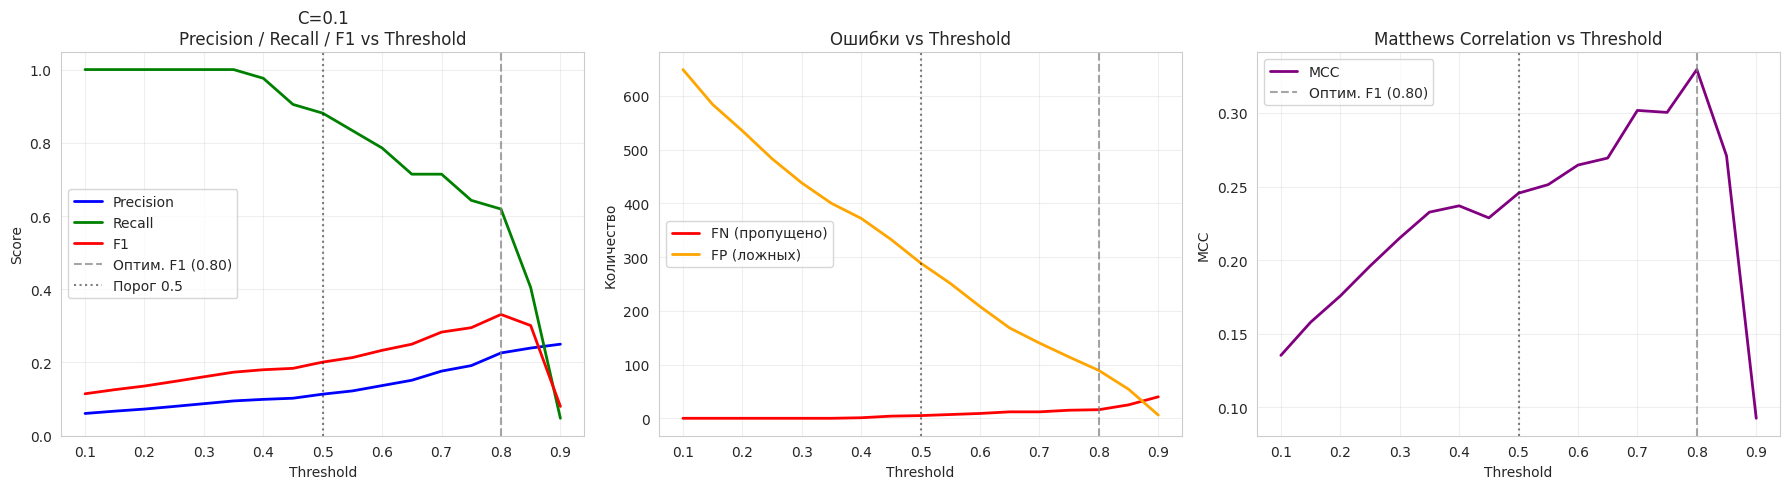

In [19]:
# 5.2 ВИЗУАЛИЗАЦИЯ МЕТРИК ПО ПОРОГАМ

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: Precision, Recall, F1 vs Threshold
ax1 = axes[0]
ax1.plot(df_thresh_best['threshold'], df_thresh_best['precision'], 'b-', label='Precision', linewidth=2)
ax1.plot(df_thresh_best['threshold'], df_thresh_best['recall'], 'g-', label='Recall', linewidth=2)
ax1.plot(df_thresh_best['threshold'], df_thresh_best['f1'], 'r-', label='F1', linewidth=2)
ax1.axvline(x=best_model_row['best_threshold_f1'], color='gray', linestyle='--', alpha=0.7, label=f"Оптим. F1 ({best_model_row['best_threshold_f1']:.2f})")
ax1.axvline(x=0.5, color='black', linestyle=':', alpha=0.5, label='Порог 0.5')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_title(f'{best_experiment_name}\nPrecision / Recall / F1 vs Threshold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: FN и FP vs Threshold
ax2 = axes[1]
ax2.plot(df_thresh_best['threshold'], df_thresh_best['FN'], 'r-', label='FN (пропущено)', linewidth=2)
ax2.plot(df_thresh_best['threshold'], df_thresh_best['FP'], 'orange', label='FP (ложных)', linewidth=2)
ax2.axvline(x=best_model_row['best_threshold_f1'], color='gray', linestyle='--', alpha=0.7)
ax2.axvline(x=0.5, color='black', linestyle=':', alpha=0.5)
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Количество')
ax2.set_title('Ошибки vs Threshold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# График 3: MCC vs Threshold
ax3 = axes[2]
ax3.plot(df_thresh_best['threshold'], df_thresh_best['mcc'], 'purple', label='MCC', linewidth=2)
ax3.axvline(x=best_model_row['best_threshold_f1'], color='gray', linestyle='--', alpha=0.7, label=f"Оптим. F1 ({best_model_row['best_threshold_f1']:.2f})")
ax3.axvline(x=0.5, color='black', linestyle=':', alpha=0.5)
ax3.set_xlabel('Threshold')
ax3.set_ylabel('MCC')
ax3.set_title('Matthews Correlation vs Threshold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

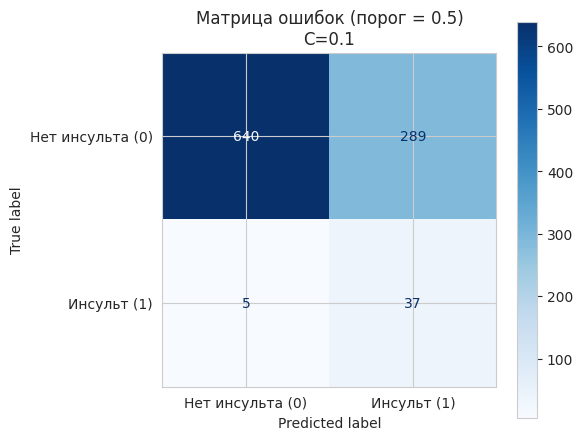

TN = 640, FP = 289
FN = 5, TP = 37


In [20]:
# 5.3 МАТРИЦА ОШИБОК (ПОРОГ 0.5)

# Получаем предсказания для лучшей модели
best_params = DEFAULT_MODEL_PARAMS.copy()
best_exp = best_model_row['experiment']
best_transform = None

# Находим параметры и трансформации этого эксперимента
for exp_name, param_changes, transform_rules in EXPERIMENTS_TO_RUN:
    if exp_name == best_exp:
        best_params.update(param_changes)
        best_transform = transform_rules
        break

# Применяем трансформации
X_train_best, X_val_best = apply_transforms(X_train, X_val, best_transform)

# Обучаем модель
best_model = LogisticRegression(**best_params)
best_model.fit(X_train_best, y_train)

# Предсказания с порогом 0.5
y_val_proba_best = best_model.predict_proba(X_val_best)[:, 1]
y_val_pred_05 = (y_val_proba_best >= 0.5).astype(int)

# Матрица ошибок
cm = confusion_matrix(y_val, y_val_pred_05)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Нет инсульта (0)', 'Инсульт (1)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f'Матрица ошибок (порог = 0.5)\n{best_exp}')
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm.ravel()
print(f"TN = {TN}, FP = {FP}")
print(f"FN = {FN}, TP = {TP}")

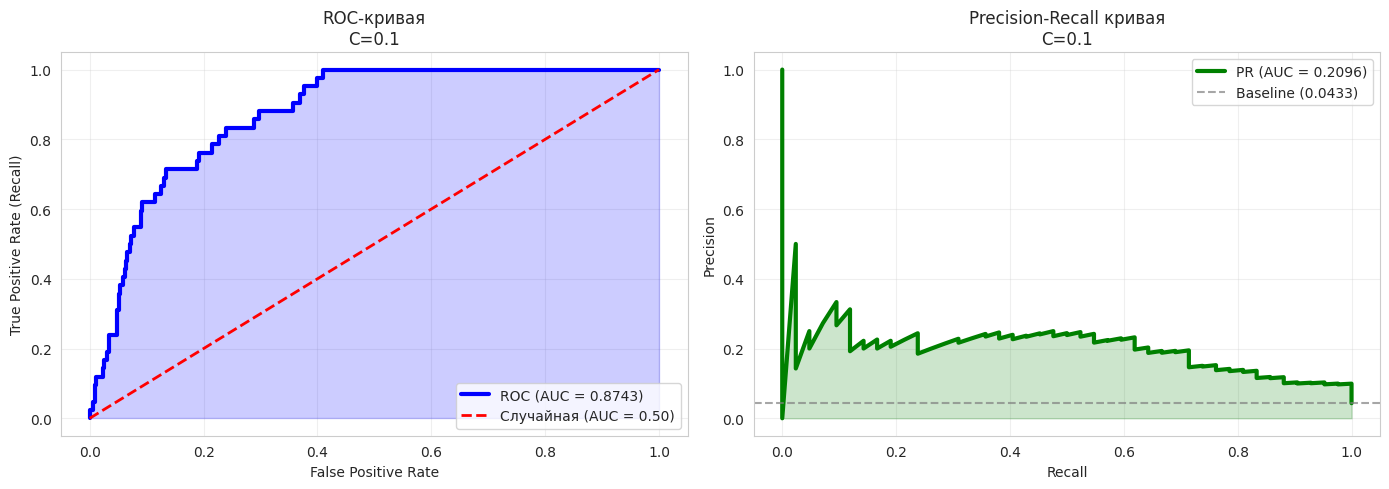

In [21]:
# 5.4 ROC И PR КРИВЫЕ

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC-кривая
fpr, tpr, _ = roc_curve(y_val, y_val_proba_best)
auc_roc = best_model_row['auc_roc']

ax1 = axes[0]
ax1.plot(fpr, tpr, 'b-', linewidth=3, label=f'ROC (AUC = {auc_roc:.4f})')
ax1.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Случайная (AUC = 0.50)')
ax1.fill_between(fpr, tpr, alpha=0.2, color='blue')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.set_title(f'ROC-кривая\n{best_exp}')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Precision-Recall кривая
precisions, recalls, _ = precision_recall_curve(y_val, y_val_proba_best)
auc_pr = best_model_row['auc_pr']

ax2 = axes[1]
ax2.plot(recalls, precisions, 'g-', linewidth=3, label=f'PR (AUC = {auc_pr:.4f})')
ax2.axhline(y=y_val.mean(), color='gray', linestyle='--', alpha=0.7,
            label=f'Baseline ({y_val.mean():.4f})')
ax2.fill_between(recalls, precisions, alpha=0.2, color='green')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title(f'Precision-Recall кривая\n{best_exp}')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# БЛОК 6. СТАТИСТИЧЕСКИЙ АНАЛИЗ

In [22]:
# 6.1 СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ КОЭФФИЦИЕНТОВ

# Добавляем константу для statsmodels
X_train_sm = sm.add_constant(X_train_best)

# Обучаем модель через statsmodels для получения p-value
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit(disp=0)

# Таблица с коэффициентами, p-value и доверительными интервалами
coef_table = pd.DataFrame({
    'Признак': ['const'] + list(X_train_best.columns),
    'Коэффициент': result.params.values,
    'Std.Error': result.bse.values,
    'z-value': result.tvalues.values,
    'p-value': result.pvalues.values,
    'CI_lower': result.conf_int()[0].values,
    'CI_upper': result.conf_int()[1].values
})

# Добавляем значимость
coef_table['Значим (p<0.05)'] = coef_table['p-value'].apply(lambda p: '✅ Да' if p < 0.05 else '❌ Нет')

print("📊 СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ КОЭФФИЦИЕНТОВ")
print("="*100)
display(coef_table.round(4))

📊 СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ КОЭФФИЦИЕНТОВ


,Признак,Коэффициент,Std.Error,z-value,p-value,CI_lower,CI_upper,Значим (p<0.05)
0,const,-4.1216,0.1967,-20.9514,0.0000,-4.5071,-3.7360,✅ Да
1,age,1.9770,0.2931,6.7458,0.0000,1.4026,2.5514,✅ Да
2,avg_glucose_level,0.1213,0.0617,1.9660,0.0493,0.0004,0.2422,✅ Да
3,bmi,0.1073,0.1412,0.7596,0.4475,-0.1695,0.3840,❌ Нет
4,cardio_risk,0.5564,0.2092,2.6597,0.0078,0.1464,0.9664,✅ Да
5,marriage_risk_senior_married,-0.9904,0.3754,-2.6384,0.0083,-1.7262,-0.2547,✅ Да
6,marriage_risk_senior_unmarried,-0.3960,0.5074,-0.7805,0.4351,-1.3904,0.5985,❌ Нет


In [23]:
# 6.2 ODDS RATIO С ИНТЕРПРЕТАЦИЕЙ

# Расчёт Odds Ratio и доверительных интервалов
coef_table['Odds_Ratio'] = np.exp(coef_table['Коэффициент'])
coef_table['OR_CI_lower'] = np.exp(coef_table['CI_lower'])
coef_table['OR_CI_upper'] = np.exp(coef_table['CI_upper'])

# Интерпретация
def interpret_or(row):
    if row['Признак'] == 'const':
        return '—'

    or_val = row['Odds_Ratio']
    ci_low = row['OR_CI_lower']
    ci_up = row['OR_CI_upper']
    p_val = row['p-value']

    if p_val >= 0.05:
        return 'Статистически не значим'

    if or_val > 1:
        if ci_low > 1:
            return f'✅ Повышает риск в {or_val:.2f} раз (значимо)'
        else:
            return f'🟡 Повышает риск в {or_val:.2f} раз (но CI включает 1)'
    else:
        if ci_up < 1:
            return f'🔻 Понижает риск в {1/or_val:.2f} раз (значимо)'
        else:
            return f'🟡 Понижает риск в {1/or_val:.2f} раз (но CI включает 1)'

coef_table['Интерпретация'] = coef_table.apply(interpret_or, axis=1)

print("📊 ODDS RATIO И ИНТЕРПРЕТАЦИЯ")
print("="*100)
display_cols = ['Признак', 'Odds_Ratio', 'OR_CI_lower', 'OR_CI_upper', 'p-value', 'Интерпретация']
display(coef_table[display_cols].round(4))

📊 ODDS RATIO И ИНТЕРПРЕТАЦИЯ


,Признак,Odds_Ratio,OR_CI_lower,OR_CI_upper,p-value,Интерпретация
0,const,0.0162,0.0110,0.0238,0.0000,—
1,age,7.2211,4.0658,12.8253,0.0000,✅ Повышает риск в 7.22 раз (значимо)
2,avg_glucose_level,1.1290,1.0004,1.2741,0.0493,✅ Повышает риск в 1.13 раз (значимо)
3,bmi,1.1132,0.8441,1.4682,0.4475,Статистически не значим
4,cardio_risk,1.7444,1.1576,2.6285,0.0078,✅ Повышает риск в 1.74 раз (значимо)
5,marriage_risk_senior_married,0.3714,0.1780,0.7752,0.0083,🔻 Понижает риск в 2.69 раз (значимо)
6,marriage_risk_senior_unmarried,0.6730,0.2490,1.8193,0.4351,Статистически не значим


# БЛОК 7. ТЕСТИРОВАНИЕ МОДЕЛИ

In [24]:
# 7.1 ФИНАЛЬНОЕ ОБУЧЕНИЕ НА TRAIN+VAL

# Объединение train и val
X_train_full = pd.concat([X_train_best, X_val_best])
y_train_full = pd.concat([y_train, y_val])

print(f"Train+Val: {X_train_full.shape[0]} примеров, {X_train_full.shape[1]} признаков")

# Финальное обучение
final_model = LogisticRegression(**best_params)
final_model.fit(X_train_full, y_train_full)

print("✅ Финальная модель обучена на train+val")

Train+Val: 3882 примеров, 6 признаков
✅ Финальная модель обучена на train+val


In [25]:
# 7.2 ТЕСТИРОВАНИЕ ФИНАЛЬНОЙ МОДЕЛИ

# Применяем те же трансформации к тестовым данным
_, X_test_best = apply_transforms(X_train, X_test, best_transform)

# Предсказания
y_test_proba = final_model.predict_proba(X_test_best)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)

# Метрики
test_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_mcc = matthews_corrcoef(y_test, y_test_pred)

# Матрица ошибок
cm_test = confusion_matrix(y_test, y_test_pred)
TN, FP, FN, TP = cm_test.ravel()

print("="*60)
print("📊 РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("="*60)
print(f"ROC-AUC:     {test_auc:.4f}")
print(f"PR-AUC:      {test_pr_auc:.4f}")
print(f"Recall:      {test_recall:.4f}")
print(f"Precision:   {test_precision:.4f}")
print(f"F1-score:    {test_f1:.4f}")
print(f"MCC:         {test_mcc:.4f}")
print()
print("Матрица ошибок:")
print(f"   TN = {TN}, FP = {FP}")
print(f"   FN = {FN}, TP = {TP}")

📊 РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ
ROC-AUC:     0.8480
PR-AUC:      0.1791
Recall:      0.8571
Precision:   0.1150
F1-score:    0.2028
MCC:         0.2433

Матрица ошибок:
   TN = 652, FP = 277
   FN = 6, TP = 36


In [26]:
# 7.3 СРАВНЕНИЕ VALIDATION vs TEST

comparison_val_test = pd.DataFrame({
    'Выборка': ['Validation', 'Test'],
    'ROC-AUC': [best_model_row['auc_roc'], test_auc],
    'PR-AUC': [best_model_row['auc_pr'], test_pr_auc],
    'Recall': [best_model_row['recall_05'], test_recall],
    'Precision': [best_model_row['precision_05'], test_precision],
    'F1': [best_model_row['f1_05'], test_f1],
    'FN': [best_model_row['FN_05'], FN],
    'FP': [best_model_row['FP_05'], FP]
})

print("📊 СРАВНЕНИЕ VALIDATION vs TEST")
print("="*80)
display(comparison_val_test.round(4))

# -----------------------------------------------------------------------------
# ПРОВЕРКА СТАБИЛЬНОСТИ (ПЕРЕОБУЧЕНИЕ)
# -----------------------------------------------------------------------------
print("\n🔍 ПРОВЕРКА СТАБИЛЬНОСТИ МОДЕЛИ:")
print("-"*40)

# Пороги для оценки
GAP_AUC_THRESHOLD = 0.03
GAP_RECALL_THRESHOLD = 0.10

auc_gap = best_model_row['auc_roc'] - test_auc
recall_gap = best_model_row['recall_05'] - test_recall

# Оценка стабильности по AUC
if abs(auc_gap) <= GAP_AUC_THRESHOLD:
    auc_status = "✅"
    auc_text = f"отличная (gap = {auc_gap:.4f})"
elif abs(auc_gap) <= 0.05:
    auc_status = "🟡"
    auc_text = f"умеренный gap = {auc_gap:.4f}"
else:
    auc_status = "🔴"
    auc_text = f"критичный gap = {auc_gap:.4f}"

# Оценка стабильности по Recall
if abs(recall_gap) <= GAP_RECALL_THRESHOLD:
    recall_status = "✅"
    recall_text = f"отличная (gap = {recall_gap:.4f})"
else:
    recall_status = "🔴"
    recall_text = f"большой gap = {recall_gap:.4f}"

print(f"{auc_status} ROC-AUC: {auc_text}")
print(f"{recall_status} Recall: {recall_text}")

# Итоговый вердикт
if auc_status == "✅" and recall_status == "✅":
    stability = "✅ СТАБИЛЬНА"
    verdict = "Модель хорошо обобщается, переобучения нет."
elif auc_status == "🔴" or recall_status == "🔴":
    stability = "🔴 НЕСТАБИЛЬНА"
    verdict = "Обнаружены признаки переобучения. Рекомендуется упростить модель или увеличить регуляризацию."
else:
    stability = "🟡 УМЕРЕННАЯ"
    verdict = "Есть небольшой gap. Можно попробовать увеличить регуляризацию."

print("\n" + "="*40)
print(f"🏆 ИТОГОВЫЙ ВЕРДИКТ: {stability}")
print(f"   {verdict}")
print("="*40)

📊 СРАВНЕНИЕ VALIDATION vs TEST


,Выборка,ROC-AUC,PR-AUC,Recall,Precision,F1,FN,FP
0,Validation,0.8743,0.2096,0.8810,0.1135,0.2011,5.0,289.0
1,Test,0.8480,0.1791,0.8571,0.1150,0.2028,6.0,277.0



🔍 ПРОВЕРКА СТАБИЛЬНОСТИ МОДЕЛИ:
----------------------------------------
✅ ROC-AUC: отличная (gap = 0.0262)
✅ Recall: отличная (gap = 0.0238)

🏆 ИТОГОВЫЙ ВЕРДИКТ: ✅ СТАБИЛЬНА
   Модель хорошо обобщается, переобучения нет.


# БЛОК 8. СОХРАНЕНИЕ РЕЗУЛЬТАТОВ

In [27]:
# 8.1 СОХРАНЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ

# Создание папки для финальной модели
final_model_path = os.path.join(MODELS_PATH, 'LogisticRegression_Final')
os.makedirs(final_model_path, exist_ok=True)

# Сохранение модели
model_file = os.path.join(final_model_path, 'model.pkl')
joblib.dump(final_model, model_file)

# Сохранение метаданных
metadata_final = {
    'model_type': 'LogisticRegression',
    'experiment_name': best_exp,
    'params': best_params,
    'transform_rules': best_transform,
    'feature_columns': list(X_train_best.columns),
    'val_metrics': {
        'auc_roc': best_model_row['auc_roc'],
        'auc_pr': best_model_row['auc_pr'],
        'recall_05': best_model_row['recall_05'],
        'precision_05': best_model_row['precision_05'],
        'f1_05': best_model_row['f1_05']
    },
    'test_metrics': {
        'auc_roc': test_auc,
        'auc_pr': test_pr_auc,
        'recall': test_recall,
        'precision': test_precision,
        'f1': test_f1
    }
}

metadata_file = os.path.join(final_model_path, 'metadata.json')
with open(metadata_file, 'w', encoding='utf-8') as f:
    json.dump(metadata_final, f, indent=2, ensure_ascii=False)

print(f"✅ Модель сохранена: {model_file}")
print(f"✅ Метаданные сохранены: {metadata_file}")

✅ Модель сохранена: /content/drive/MyDrive/ml_learning/datasets/stroke/models/LogisticRegression_Final/model.pkl
✅ Метаданные сохранены: /content/drive/MyDrive/ml_learning/datasets/stroke/models/LogisticRegression_Final/metadata.json


In [28]:
# 8.2 СОХРАНЕНИЕ ПРЕДСКАЗАНИЙ НА ТЕСТЕ

# Создание DataFrame с предсказаниями
test_predictions = pd.DataFrame({
    'y_true': y_test.values,
    'y_proba': y_test_proba,
    'y_pred': y_test_pred
})

# Добавляем вероятности для обоих классов
test_proba_full = final_model.predict_proba(X_test_best)
test_predictions['proba_class_0'] = test_proba_full[:, 0]
test_predictions['proba_class_1'] = test_proba_full[:, 1]

# Сохранение
pred_file = os.path.join(final_model_path, 'test_predictions.csv')
test_predictions.to_csv(pred_file, index=False)

print(f"✅ Предсказания сохранены: {pred_file}")
print(f"   Всего примеров: {len(test_predictions)}")
print(f"   Предсказано инсультов: {test_predictions['y_pred'].sum()}")

✅ Предсказания сохранены: /content/drive/MyDrive/ml_learning/datasets/stroke/models/LogisticRegression_Final/test_predictions.csv
   Всего примеров: 971
   Предсказано инсультов: 313


In [29]:
# 8.3 СОХРАНЕНИЕ ТАБЛИЦ ЭКСПЕРИМЕНТОВ

# Сохраняем полную таблицу сравнения
comparison_file = os.path.join(final_model_path, 'experiments_comparison.csv')
comparison_df.to_csv(comparison_file, index=False)

# Сохраняем детальные метрики лучшей модели
thresholds_file = os.path.join(final_model_path, 'best_model_thresholds.csv')
df_thresh_best.to_csv(thresholds_file, index=False)

# Сохраняем таблицу коэффициентов с p-value
coef_file = os.path.join(final_model_path, 'coefficients_stats.csv')
coef_table.to_csv(coef_file, index=False)

print(f"✅ Сводная таблица экспериментов: {comparison_file}")
print(f"✅ Метрики по порогам: {thresholds_file}")
print(f"✅ Коэффициенты со статистикой: {coef_file}")

✅ Сводная таблица экспериментов: /content/drive/MyDrive/ml_learning/datasets/stroke/models/LogisticRegression_Final/experiments_comparison.csv
✅ Метрики по порогам: /content/drive/MyDrive/ml_learning/datasets/stroke/models/LogisticRegression_Final/best_model_thresholds.csv
✅ Коэффициенты со статистикой: /content/drive/MyDrive/ml_learning/datasets/stroke/models/LogisticRegression_Final/coefficients_stats.csv


# БЛОК 9. ИТОГОВЫЙ ОТЧЁТ

In [30]:
# 9.1 ИТОГОВЫЙ ОТЧЁТ

print("\n" + "="*80)
print(f"🎉 ИТОГОВЫЙ ОТЧЁТ ПО ПРОЕКТУ: {PROJECT_NAME.upper()}")
print("="*80)

print("\n📊 ЛУЧШАЯ МОДЕЛЬ:")
print(f"   Эксперимент: {best_exp}")
print(f"   ROC-AUC (val):  {best_model_row['auc_roc']:.4f}")
print(f"   ROC-AUC (test): {test_auc:.4f}")
print(f"   Recall (test):  {test_recall:.4f}")
print(f"   Precision (test): {test_precision:.4f}")
print(f"   F1 (test):      {test_f1:.4f}")

print("\n📋 ЗНАЧИМЫЕ ПРИЗНАКИ (p < 0.05):")
significant = coef_table[coef_table['p-value'] < 0.05]
significant = significant[significant['Признак'] != 'const']
if len(significant) > 0:
    for _, row in significant.iterrows():
        direction = "↑" if row['Коэффициент'] > 0 else "↓"
        print(f"   {direction} {row['Признак']} (p={row['p-value']:.4f})")
else:
    print("   Нет статистически значимых признаков")

print("\n📁 СОХРАНЁННЫЕ ФАЙЛЫ:")
print(f"   {final_model_path}/")
print("   ├── model.pkl")
print("   ├── metadata.json")
print("   ├── test_predictions.csv")
print("   ├── experiments_comparison.csv")
print("   ├── best_model_thresholds.csv")
print("   └── coefficients_stats.csv")

print("\n" + "="*80)
print("✅ ШАБЛОН ЗАВЕРШИЛ РАБОТУ")
print("="*80)


🎉 ИТОГОВЫЙ ОТЧЁТ ПО ПРОЕКТУ: STROKE

📊 ЛУЧШАЯ МОДЕЛЬ:
   Эксперимент: C=0.1
   ROC-AUC (val):  0.8743
   ROC-AUC (test): 0.8480
   Recall (test):  0.8571
   Precision (test): 0.1150
   F1 (test):      0.2028

📋 ЗНАЧИМЫЕ ПРИЗНАКИ (p < 0.05):
   ↑ age (p=0.0000)
   ↑ avg_glucose_level (p=0.0493)
   ↑ cardio_risk (p=0.0078)
   ↓ marriage_risk_senior_married (p=0.0083)

📁 СОХРАНЁННЫЕ ФАЙЛЫ:
   /content/drive/MyDrive/ml_learning/datasets/stroke/models/LogisticRegression_Final/
   ├── model.pkl
   ├── metadata.json
   ├── test_predictions.csv
   ├── experiments_comparison.csv
   ├── best_model_thresholds.csv
   └── coefficients_stats.csv

✅ ШАБЛОН ЗАВЕРШИЛ РАБОТУ
